In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report


In [3]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
print(X_train_raw.shape)
print(y_train_raw.shape)
print(X_test_raw.shape)
print(y_test_raw.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [7]:
print(X_train_raw.dtype)
print(y_train_raw.dtype)

uint8
uint8


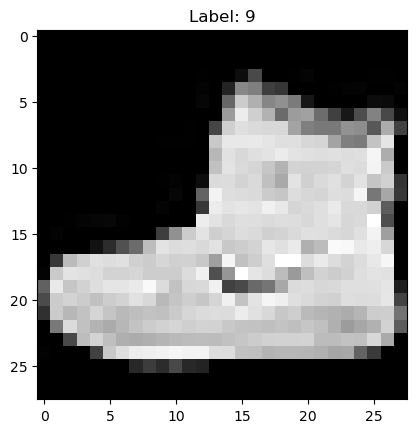

In [9]:
import matplotlib.pyplot as plt

plt.imshow(X_train_raw[0], cmap='gray')
plt.title(f"Label: {y_train_raw[0]}")
plt.show()

In [13]:
labels, counts = np.unique(y_train_raw, return_counts=True)
for label, count in zip(labels, counts):
    print(f"Label {label}: {count}")


Label 0: 6000
Label 1: 6000
Label 2: 6000
Label 3: 6000
Label 4: 6000
Label 5: 6000
Label 6: 6000
Label 7: 6000
Label 8: 6000
Label 9: 6000


In [15]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress",
               "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(class_names[y_train_raw[0]])

Ankle boot


In [17]:
import numpy as np

unique, counts = np.unique(y_train_raw, return_counts=True)
print(dict(zip(unique, counts)))

{0: 6000, 1: 6000, 2: 6000, 3: 6000, 4: 6000, 5: 6000, 6: 6000, 7: 6000, 8: 6000, 9: 6000}


In [19]:
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

In [21]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

In [25]:
print(y_train.shape)
print(y_test.shape)


(60000, 10)
(10000, 10)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [29]:
print(X_train.shape, X_val.shape, X_test.shape)

(48000, 28, 28) (12000, 28, 28) (10000, 28, 28)


In [31]:
print(np.isnan(X_train).sum())

0


In [33]:
print(X_train[0])
print(y_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [37]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

model_clf = Sequential([
    Input(shape=(28, 28)),  
    Flatten(),               
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [49]:
model_clf.compile(
    optimizer='adam',
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

In [51]:
model_clf.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7708 - loss: 0.6598
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8607 - loss: 0.3883
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8780 - loss: 0.3358
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8844 - loss: 0.3115
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8881 - loss: 0.3000


In [55]:
test_loss, test_acc = model_clf.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8712 - loss: 0.3690
Test Accuracy: 0.8676999807357788


In [59]:
predictions = model_clf.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [61]:
import numpy as np

print(np.argmax(predictions[0]))
print(y_test[0])

9
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
